# Notebook 0 — Digital-twin calibration & Time-Usage-Model (TUM) accounting

**Project:** Real Autonomy in Autonomous Haulage · *Digital-twin experiments*
**Site (anonymised):** *Mine A*, open-pit copper mine, *Region R* · **Operator (anonymised):** *Company X*
**Runtime:** Google Colab (CPU is enough) · **Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` (pre-installed in Colab)

> **Central question.** Can a compact, transparent simulator reproduce the *shape* of the autonomous haul cycle and the TUM indicators seen in the operations dashboards, so that later experiments (information latency, heterogeneous communication, human-in-the-loop vs. autopoietic control) are credible?

**Role in the series.** This is the *foundation* notebook. Notebooks 1–3 re-use exactly the same simulator (`Sim`), so the calibration below is the evidence that the experiments start from a plausible operation.
**How to use this notebook.** Run the cells top to bottom (*Runtime → Run all*). Every experiment uses fixed random seeds, so you should reproduce the numbers quoted in the interpretation cells within the printed confidence intervals. Result cells are followed by an **input and output interpretation** section that states what the table or figure supports and what it does not.

**Anonymisation.** Company, mine, region and equipment identifiers were replaced (*Company X*, *Mine A*, *Region R*, shovels `SH-1…SH-5`, trucks `AHT-01…AHT-23`). The Time Usage Model codes, the ten cycle phases and the KPI definitions are kept exactly as in the source documents because they are the shared language of the analysis.


## 0. Contents
1. Model inputs, TUM mapping and assumptions
2. Shared simulator
3. Calibration against the dashboard
4. TUM accounting
5. Zero-lag dispatch benchmark
6. Verification checks
7. Structural sensitivity
8. Limitations
9. References
10. Disclaimer


## 1. Model description

### 1.1 The mining haul cycle (10 phases)
An autonomous haul truck (AHT) repeats a closed loop between a **shovel** (source) and the **crusher** (sink). The ten phases are exactly those shown in the cycle diagram and in the *Autonomous Fleet* dashboard [CYCLE][DASH]:

`Travelling Empty → Queuing at Source → Spotting at Source → Wait for load → Loading → Travelling Full → Queuing at sink → Spotting at sink → Wait for Dump → Dumping → (dispatch decision) → …`

### 1.2 Mapping to the Time Usage Model
The TUM splits calendar time into *required → available → cycle → production* time and assigns standard codes [TUM][GLOS]. The simulator records every truck-minute in exactly one bucket:

| Simulator bucket | TUM code (family) | TUM category |
|---|---|---|
| Travelling empty/full, spotting, loading, dumping | **1010** Autonomous production | Production time (value-adding) |
| Wait for load, wait for dump | **7000** Wait time (wait for dump is assigned here by assumption; the standard's 7020 is the queue at the sink) | Cycle time, *non-value-adding* |
| Queue at source | **7010** | Cycle time, non-value-adding |
| Queue at sink | **7020** | Cycle time, non-value-adding |
| Obstacle / interaction stop | **4070** Wait for access | Unscheduled *process* downtime |
| Emergency A-stop | **4110** Emergency event | Unscheduled process downtime |
| Process delays (hand-over, lock-outs, weather…) | **2xxx / 4xxx** | Scheduled / unscheduled process downtime |
| Refuel | **2020** | Scheduled process downtime |
| Wait for dispatch or approval | **4060 / 4150** (closest standard codes; there is no code for waiting for a dispatch approval) | Unscheduled process downtime |
| Breakdown | **5000** | Unscheduled *equipment* downtime |
| Autonomy hardware event | **5060** | Unscheduled equipment downtime |

Following the TUM note that *"equipment must be available before process downtime can be applied"*, equipment downtime (5xxx) is removed first to obtain **available time**; the standard parameters are then computed as

* **Availability** = available time / required time
* **Utilization** = production time / available time
* **Total utilization** = production time / calendar time
* **Annualised production time** = production time / calendar time × 8 760 h

The dashboard counts wait-for-load and wait-for-dump as *productive* and only the queues as non-productive queue time; both definitions are reported (`utilization` = dashboard definition, `utilization_tum` = strict code 1010) so nothing is hidden.

### 1.3 Simulator design (discrete time, dt = 0.25 min, 12 h shift, 1 h warm-up)
* **Fleet:** 23 AHT, 5 active shovels (`SH-1…SH-5`) and one crusher with 2 dump bays. *Caveat:* the SHOVEL page of the dashboard shows loading time on only four shovels in the reference week, and the total hours on the dashboard suggest ≈ 26 trucks; the five-shovel structure is a modelling choice whose consequences are tested in Section 7.
* **Durations:** log-normal with coefficient of variation 0.25 (0.5 for the short wait phases: wait for load and wait for dump); means from the dashboard (e.g. loading 2.42 min, spotting at source 1.03 min).
* **Geometry:** shovels differ in haul distance (travelling empty 7.0–14.4 min), reproducing the fact that pits/phases have different cycle times [DASH].
* **Reliability:** truck MTBF = 10 h and MTTR = 1.85 h, chosen so that the *simulated availability equals the dashboard's 84.4 %* (MTBF / (MTBF + MTTR)); they sit at the edge of the template thresholds (MTBF > 10 h, MTTR < 2 h [KPI]). There is no scheduled maintenance (TUM 3xxx): all equipment downtime is modelled as breakdown (5000). Shovel MTBF 30 h, MTTR 1.5 h; crusher blockages every ≈ 60 min for ≈ 7 min.
* **Process delays and autonomy events:** probabilistic, so that utilization is in the dashboard range.
* **Baseline dispatch:** a **home-allocation plan** (9-5-4-3-2), imbalanced by construction. A truck queued at an unavailable shovel is diverted after 8 min as a fail-safe, so the policy is not a permanently fixed assignment. The imbalance is a modelling device used to reproduce the source queue; it is **not** observed in the per-shovel dashboard data (Section 7).
* **Payload:** 338 t (load factor in the dashboard).

> **Modelling honesty.** Values that were *tuned* to the reference dashboard are listed in Section 3.1; values that are *assumed* (event rates, blockage times, etc.) are plausible engineering assumptions, not measurements. They are exposed in the `P` dataclass so they can be replaced with real telemetry (e.g. a FMS event export).


## 2. Simulator code (identical in Notebooks 0–3)
The cell below defines `P` (parameters), `Sim` (the digital twin), simple dispatch policies and helper functions. Read the docstrings and comments once; later notebooks only *use* it.

In [1]:
import numpy as np, pandas as pd, math
from scipy.stats import t as student_t
try:
    from IPython.display import display
except ImportError:          # plain-python fallback
    display = print
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
from collections import deque
from dataclasses import dataclass, replace

# ---------------------------------------------------------------- state ids
TE, QS, SS, WL, LD, TF, QK, SK, WD, DP, DN, RF, HD, E70, E110, E60, PD = range(17)
PHASES = ["Travelling Empty", "Queuing At Source", "Spotting At Source", "Wait for load", "Loading",
          "Travelling Full", "Queuing at sink", "Spotting at sink", "Wait for Dump", "Dumping"]
SLOT_NAME = PHASES + ["Breakdown (5000)", "Refuel (2020)", "Hold: wait dispatch/approval (4060/4150)",
                      "Obstacle / interaction stop (4070)", "Emergency A-stop (4110)", "Autonomy HW event (5060)", "Process delays (2xxx/4xxx)"]
SLOT_CODE = [1010, 7010, 1010, 7000, 1010, 1010, 7020, 1010, 7000, 1010, 5000, 2020, 4060, 4070, 4110, 5060, 4000]
QUEUE_SLOTS = (QS, QK)              # non value-adding queues (TUM 7010 / 7020)
DOWN_SLOTS = (DN, E60)              # equipment downtime (TUM 5xxx)
CYCLE_SLOTS = list(range(10))

# Reference values read from the (anonymised) operations dashboard, 8-16 Mar window
REF = {"Travelling Empty": 9.90, "Queuing At Source": 6.06, "Spotting At Source": 1.03, "Wait for load": 1.24,
       "Loading": 2.42, "Travelling Full": 9.14, "Queuing at sink": 1.56, "Spotting at sink": 0.70,
       "Wait for Dump": 0.37, "Dumping": 1.09}
REF_KPI = {"cycle_time": 33.51, "availability": 84.39, "utilization": 66.20, "tph_productive": 787.01,
           "hang_time": 2.24, "load_factor_t": 338.0}


@dataclass
class P:
    n_trucks: int = 23
    T: float = 720.0            # one 12 h shift, minutes
    warm: float = 60.0          # warm-up discarded from KPIs
    dt: float = 0.25
    payload: float = 338.0
    # per-shovel geometry (minutes) -> 5 active shovels (a 6th is out of service in the reference data)
    te: tuple = (7.0, 9.1, 10.2, 12.8, 14.4)
    tf: tuple = (6.6, 8.6, 9.6, 11.8, 13.4)
    load: tuple = (2.2, 2.4, 2.4, 2.6, 2.7)
    spot_src: float = 1.03
    wait_load: float = 1.24
    spot_sink: float = 0.70
    wait_dump: float = 0.37
    dump: float = 1.09
    sink_bays: int = 2
    sink_block_mtbf: float = 60.0   # crusher / dump-pocket blockages (min between events)
    sink_block_min: float = 7.0
    static_alloc: tuple = (9, 5, 4, 3, 2)
    cv: float = 0.25
    mtbf_h: float = 10.0
    mttr_h: float = 1.85
    shovel_mtbf_h: float = 30.0
    shovel_mttr_h: float = 1.5
    refuel_min: float = 12.0
    proc_p: float = 0.40        # prob. of a process delay (shift hand-over, lock-outs, weather...) at a decision point
    proc_mean: float = 8.0
    # interaction with heterogeneous traffic (manual / light vehicles / other autonomy stacks)
    lam_int: float = 0.020      # events per travelling minute
    comms_cov: float = 0.5      # 0 = no heterogeneous comms, 1 = full interoperability
    d_soft: float = 0.4
    d_hard: float = 3.5
    p_astop: float = 0.06       # probability that an uncoordinated hard stop escalates to an A-stop
    d_astop: float = 14.0
    lam_hw: float = 0.0015      # autonomy hardware events per travelling minute
    d_hw: float = 6.0
    handshake_gain: float = 0.0  # fraction of spot/wait-for-load time removed by full truck-shovel comms
    shovel_outages: tuple = ()  # ((shovel, start_min, end_min), ...)
    system_outages: tuple = ()  # ((start_min, end_min), ...) central FMS / network outage
    fallback_min: float = 10.0  # after this long in an outage, centralised policies fall back to the static plan
    seed: int = 0


HALF_DT = 0.125   # a timer that is decremented every dt overshoots by dt/2 on average -> compensate


def _ln(rng, mean, cv):
    s2 = math.log(1 + cv * cv)
    return max(0.02, rng.lognormal(math.log(mean) - s2 / 2, math.sqrt(s2)) - HALF_DT)


class Sim:
    def __init__(self, p: P, policy):
        self.p, self.policy = p, policy
        seed_seq = np.random.SeedSequence(p.seed)
        env_seed, policy_seed = seed_seq.spawn(2)
        self.rng = np.random.default_rng(env_seed)
        self.policy_rng = np.random.default_rng(policy_seed)
        N, M = p.n_trucks, len(p.te)
        self.N, self.M = N, M
        self.state = [TE] * N; self.left = [0.0] * N; self.tgt = [0] * N
        self.evt_left = [0.0] * N; self.evt_slot = [E70] * N
        self.hold_left = [0.0] * N; self.pending_tgt = [0] * N
        self.disp_t = [0.0] * N; self.disp_phi = [None] * N
        self.cycle_start = [0.0] * N
        self.fail_t = [self.rng.exponential(p.mtbf_h * 60) for _ in range(N)]
        self.refuel_t = [self.rng.uniform(200, 560) for _ in range(N)]
        self.acct = np.zeros((N, 17))
        self.shq = [[] for _ in range(M)]; self.occ = [-1] * M
        self.committed = [0] * M
        self.down = [False] * M
        self.sh_next_fail = [self.rng.exponential(p.shovel_mtbf_h * 60) for _ in range(M)]
        self.sh_up_at = [0.0] * M
        self.idle = np.zeros(M); self.loads = np.zeros(M); self.qtime = np.zeros(M)
        self.skq = []; self.sink_occ = 0
        self.sink_next_block = self.rng.exponential(p.sink_block_mtbf); self.sink_blocked_until = 0.0
        self.dump_times = []
        self.trips = 0; self.cycles = []; self.n_evt = {E70: 0, E110: 0, E60: 0}
        self.n_touch = 0; self.hist = []; self.dlog = deque()
        self.t = 0.0; self.k = 0
        self.home = []
        for a, n in enumerate(p.static_alloc):
            self.home += [a] * n
        self.home = (self.home + [0] * N)[:N]
        self.qdown_since = [None] * N
        self.tons_log = []
        for i in range(N):
            a = self._pick(i)
            self._depart(i, a, frac=self.rng.uniform(0.2, 1.0))

    # ------------------------------------------------------------ observation API used by policies
    def obs(self, lag):
        if lag <= 0 or not self.hist:
            return list(self.committed), list(self.down)
        idx = max(0, len(self.hist) - 1 - int(round(lag / self.p.dt)))
        return self.hist[idx]

    def recent(self, lag):
        c = [0] * self.M
        for (t, a) in self.dlog:
            if t > self.t - lag:
                c[a] += 1
        return c

    def in_outage(self):
        for (a, b) in self.p.system_outages:
            if a <= self.t < b:
                return a
        return None

    def phys_queue(self):
        return [len(q) + (1 if self.occ[a] >= 0 else 0) for a, q in enumerate(self.shq)]

    # ------------------------------------------------------------ helpers
    def _pick(self, i, redirect=False):
        a = self.policy.choose(self, i, redirect)
        self.disp_phi[i] = getattr(self.policy, "last_phi", None)
        return a

    def _depart(self, i, a, frac=1.0):
        p = self.p
        self.tgt[i] = a; self.committed[a] += 1; self.disp_t[i] = self.t
        self.dlog.append((self.t, a))
        while self.dlog and self.dlog[0][0] < self.t - 30:
            self.dlog.popleft()
        self.state[i] = TE
        self.left[i] = _ln(self.rng, p.te[a], p.cv) * frac

    def _next(self, i):
        """decision point after dumping / repair / refuel"""
        p = self.p
        if self.t >= self.fail_t[i]:
            self.state[i] = DN
            self.left[i] = _ln(self.rng, p.mttr_h * 60, 0.5)
            self.fail_t[i] = self.t + self.left[i] + self.rng.exponential(p.mtbf_h * 60)
            return
        if self.t >= self.refuel_t[i]:
            self.state[i] = RF; self.left[i] = _ln(self.rng, p.refuel_min, 0.2)
            self.refuel_t[i] = 1e9
            return
        if self.rng.random() < p.proc_p:
            self.state[i] = PD; self.left[i] = _ln(self.rng, p.proc_mean, 0.6)
            return
        self._dispatch(i)

    def _dispatch(self, i):
        p = self.p
        pol = self.policy
        if getattr(pol, "central", False):
            o = self.in_outage()
            if o is not None:
                if self.t - o < p.fallback_min:
                    self.state[i] = HD; self.left[i] = p.dt
                    self.pending_tgt[i] = -1
                    return
                a = self.home[i]
                self._depart(i, a); self.disp_phi[i] = None
                return
        a = self._pick(i)
        d = getattr(pol, "delay", lambda s, i: 0.0)(self, i)
        if d > 0:
            self.pending_tgt[i] = a; self.state[i] = HD; self.left[i] = d
            self.committed[a] += 1  # commitment visible immediately
            return
        self._depart(i, a)

    def _spawn_event(self, i):
        p, r = self.p, self.rng
        cov = p.comms_cov
        if r.random() < p.lam_int * p.dt:
            self.evt_slot[i] = E70
            if r.random() < cov:
                self.evt_left[i] = r.exponential(p.d_soft)
            else:
                self.evt_left[i] = r.exponential(p.d_hard)
                if r.random() < p.p_astop:
                    self.evt_slot[i] = E110
                    self.evt_left[i] = _ln(r, self.policy.astop_delay(self) if hasattr(self.policy, "astop_delay") else p.d_astop, 0.4)
                    self.n_evt[E110] += 1
                    self.n_touch += getattr(self.policy, "astop_touch", 1)
            self.n_evt[E70] += 1
        elif r.random() < p.lam_hw * p.dt:
            self.evt_slot[i] = E60; self.evt_left[i] = _ln(r, p.d_hw, 0.4); self.n_evt[E60] += 1

    # ------------------------------------------------------------ main loop
    def _truck(self, i):
        p, dt = self.p, self.p.dt
        if self.evt_left[i] > 0:
            self.acct[i][self.evt_slot[i]] += dt; self.evt_left[i] -= dt
            return
        st = self.state[i]
        self.acct[i][st] += dt
        if st in (TE, TF):
            self._spawn_event(i)
        if st == QS:
            a = self.tgt[i]
            if self.down[a]:
                if self.qdown_since[i] is None:
                    self.qdown_since[i] = self.t
                if self.t - self.qdown_since[i] >= self.policy.redirect_delay and not (
                        getattr(self.policy, "central", False) and self.in_outage() is not None):
                    self.shq[a].remove(i); self.committed[a] -= 1; self.qdown_since[i] = None
                    b = self._pick(i, redirect=True)
                    self._depart(i, b, frac=0.6)
            else:
                self.qdown_since[i] = None
            return
        if st == QK:
            return
        if st == HD:
            self.left[i] -= dt
            if self.pending_tgt[i] == -1:      # waiting out a system outage
                if self.in_outage() is None or self.t - self.in_outage() >= p.fallback_min:
                    self._dispatch(i)
                return
            if self.left[i] <= 0:
                a = self.pending_tgt[i]; self.committed[a] -= 1
                self._depart(i, a)
            return
        self.left[i] -= dt
        if self.left[i] > 0:
            return
        a = self.tgt[i]
        if st == TE:
            self.state[i] = QS; self.shq[a].append(i)
        elif st == SS:
            self.state[i] = WL; self.left[i] = _ln(self.rng, p.wait_load * (1 - 0.7 * p.handshake_gain), p.cv * 2)
        elif st == WL:
            self.state[i] = LD; self.left[i] = _ln(self.rng, p.load[a], p.cv)
        elif st == LD:
            self.state[i] = TF; self.left[i] = _ln(self.rng, p.tf[a], p.cv)
            self.occ[a] = -1; self.committed[a] -= 1; self.loads[a] += 1
            if hasattr(self.policy, "on_loaded"):
                self.policy.on_loaded(self, i, a, self.t - self.disp_t[i])
        elif st == TF:
            self.state[i] = QK; self.skq.append(i)
        elif st == SK:
            self.state[i] = WD; self.left[i] = _ln(self.rng, p.wait_dump, p.cv * 2)
        elif st == WD:
            self.state[i] = DP; self.left[i] = _ln(self.rng, p.dump, p.cv)
        elif st == DP:
            self.sink_occ -= 1
            if self.t >= p.warm:
                self.trips += 1; self.cycles.append(self.t - self.cycle_start[i]); self.dump_times.append(self.t)
            self.cycle_start[i] = self.t
            self._next(i)
        elif st in (DN, RF):
            self._next(i)
        elif st == PD:
            self._dispatch(i)

    def _shovels(self):
        p = self.p
        for a in range(self.M):
            # scripted + random outages (start only when shovel is free)
            forced = any(s == a and b <= self.t < c for (s, b, c) in p.shovel_outages)
            if self.down[a]:
                if not forced and self.t >= self.sh_up_at[a]:
                    self.down[a] = False
                    self.sh_next_fail[a] = self.t + self.rng.exponential(p.shovel_mtbf_h * 60)
            elif self.occ[a] == -1 and (forced or self.t >= self.sh_next_fail[a]):
                self.down[a] = True
                self.sh_up_at[a] = self.t + (0 if forced else _ln(self.rng, p.shovel_mttr_h * 60, 0.5))
            if not self.down[a] and self.occ[a] == -1 and self.shq[a]:
                i = self.shq[a].pop(0)
                self.occ[a] = i; self.state[i] = SS
                self.left[i] = _ln(self.rng, p.spot_src * (1 - 0.7 * p.handshake_gain), p.cv)
            if self.t >= p.warm:
                self.qtime[a] += p.dt * len(self.shq[a])
            if not self.down[a] and self.occ[a] == -1 and not self.shq[a] and self.t >= p.warm:
                self.idle[a] += p.dt

    def _sink(self):
        p = self.p
        if self.t >= self.sink_next_block:
            self.sink_blocked_until = self.t + _ln(self.rng, p.sink_block_min, 0.5)
            self.sink_next_block = self.sink_blocked_until + self.rng.exponential(p.sink_block_mtbf)
        if self.t < self.sink_blocked_until:
            return
        while self.sink_occ < p.sink_bays and self.skq:
            i = self.skq.pop(0); self.sink_occ += 1
            self.state[i] = SK; self.left[i] = _ln(self.rng, p.spot_sink, p.cv)

    def run(self):
        p = self.p
        for k in range(int(p.T / p.dt)):
            self.k = k; self.t = k * p.dt
            if abs(self.t - p.warm) < 1e-9:
                self.acct[:] = 0; self.idle[:] = 0; self.qtime[:] = 0; self.trips = 0; self.cycles = []; self.loads[:] = 0
                self.n_evt = {E70: 0, E110: 0, E60: 0}; self.n_touch = 0; self.dump_times = []
            for i in range(self.N):
                self._truck(i)
            self._shovels(); self._sink()
            self.hist.append((list(self.committed), list(self.down)))
            if len(self.hist) > 200:
                self.hist.pop(0)
        return self.metrics()

    def metrics(self):
        p = self.p
        tot = self.acct.sum()
        by = self.acct.sum(axis=0)
        down = sum(by[s] for s in DOWN_SLOTS)
        prod = sum(by[s] for s in CYCLE_SLOTS if s not in QUEUE_SLOTS)      # dashboard definition: cycle minus queues
        tum_prod = by[[TE, SS, LD, TF, SK, DP]].sum()                      # strict TUM 1010
        hrs = (p.T - p.warm) / 60
        tons = self.trips * p.payload
        trips = max(self.trips, 1)
        m = dict(trips=self.trips, tons=tons, tph_fleet=tons / hrs,
                 availability=100 * (1 - down / tot), utilization=100 * prod / (tot - down),
                 utilization_tum=100 * tum_prod / (tot - down),
                 tph_productive=tons / (prod / 60) if prod > 0 else 0.0,
                 cycle_time=float(by[CYCLE_SLOTS].sum() / trips),
                 cycle_wall=float(np.mean(self.cycles)) if self.cycles else float("nan"),
                 hang_time=float(self.idle.sum() / max(self.loads.sum(), 1)),
                 queue_src=by[QS] / trips, queue_sink=by[QK] / trips,
                 astops=self.n_evt[E110], stops=self.n_evt[E70], hw_events=self.n_evt[E60],
                 touches=self.n_touch, annual_Mt=tons / hrs * 8760 / 1e6,
                 loads=list(self.loads), idle=list(self.idle), qtime=list(self.qtime))
        for s in range(17):
            m["min_" + str(s)] = by[s] / trips           # minutes per trip in each slot
            m["share_" + str(s)] = 100 * by[s] / tot
        return m


# ================================================================ policies
class Static:
    name = "Static plan"; central = False; redirect_delay = 8.0
    def choose(self, s, i, redirect=False):
        return s.home[i] if not redirect else int(np.argmin([s.p.te[a] if not s.down[a] else 99 for a in range(s.M)]))


class Nearest:
    name = "Nearest shovel"; central = True; redirect_delay = 1.0
    def choose(self, s, i, redirect=False):
        return int(np.argmin([s.p.te[a] + (99 if s.down[a] else 0) for a in range(s.M)]))


class GreedyObs:
    """expected-time greedy on a (possibly stale) telemetry snapshot; svc = minutes of shovel time per truck"""
    central = True; redirect_delay = 1.0
    def __init__(self, lag=0.0, svc=4.5, noise=0.0, name=None):
        self.lag, self.svc, self.noise = lag, svc, noise
        self.name = name or f"Greedy (info lag {lag:g} min)"
    def choose(self, s, i, redirect=False):
        c, dn = s.obs(self.lag)
        est = []
        for a in range(s.M):
            e = max(s.p.te[a], c[a] * self.svc)
            if dn[a]:
                e += 60
            if self.noise:
                e *= s.policy_rng.lognormal(0, self.noise)
            est.append(e)
        return int(np.argmin(est))


# ================================================================ experiment helpers
def replicate(make_policy, n=20, seed0=0, keep_sims=False, **kw):
    """Run n independent replications (different random seeds) and return a DataFrame of KPIs."""
    rows, sims = [], []
    for k in range(n):
        sim = Sim(P(seed=seed0 + k, **kw), make_policy())
        m = sim.run(); m["seed"] = seed0 + k
        rows.append(m); sims.append(sim)
    df = pd.DataFrame(rows)
    return (df, sims) if keep_sims else df


def ci95(x):
    """Two-sided 95% half-width using Student's t for the finite replication count."""
    x = np.asarray(x, float)
    if len(x) < 2:
        return float("nan")
    return student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))


def tons_series(sim, bin_min=30):
    edges = np.arange(sim.p.warm, sim.p.T + 1e-9, bin_min)
    h, _ = np.histogram(sim.dump_times, bins=edges)
    return edges[:-1] + bin_min / 2, h * sim.p.payload / (bin_min / 60)     # t/h in each bin


def summarize(df, cols=("tph_fleet", "cycle_time", "queue_src", "queue_sink", "availability", "utilization", "tph_productive")):
    return pd.DataFrame({c: [f"{df[c].mean():.1f} ± {ci95(df[c]):.1f}"] for c in cols})


## 3. Calibration against the dashboard
We run 30 independent replications of the **static-plan baseline** and compare with the reference values read from the *Autonomous Fleet* dashboard [DASH] and the cycle diagram [CYCLE].

> **What "calibration" means here.** Most rows below are *targets that were tuned by hand* (allocation of trucks to shovels, probability of process delays, crusher blockages, MTBF/MTTR), so agreement on them is expected and is **not** independent validation. Section 3.1 states, for every quantity, whether it is an *input*, a *tuned target*, *by construction*, or an *independent check*.

,Phase,Dashboard (min),Simulated (min),±95% CI,Error %
0,Travelling Empty,9.90,9.41,0.10,-4.98
1,Queuing At Source,6.06,5.81,0.63,-4.18
2,Spotting At Source,1.03,1.03,0.01,-0.21
3,Wait for load,1.24,1.24,0.01,0.02
4,Loading,2.42,2.36,0.01,-2.64
5,Travelling Full,9.14,8.70,0.07,-4.84
6,Queuing at sink,1.56,1.54,0.19,-1.38
7,Spotting at sink,0.70,0.70,0.00,0.10
8,Wait for Dump,0.37,0.38,0.00,1.54
9,Dumping,1.09,1.09,0.01,-0.12


,KPI,Dashboard,Simulated,±95% CI,Error %
0,Availability (%),84.39,85.24,0.99,1.01
1,Utilization (%),66.20,67.31,1.10,1.67
2,Throughput per productive hour (t/h),787.01,814.86,5.02,3.54
3,Shovel hang time (min),2.24,4.41,0.12,96.76


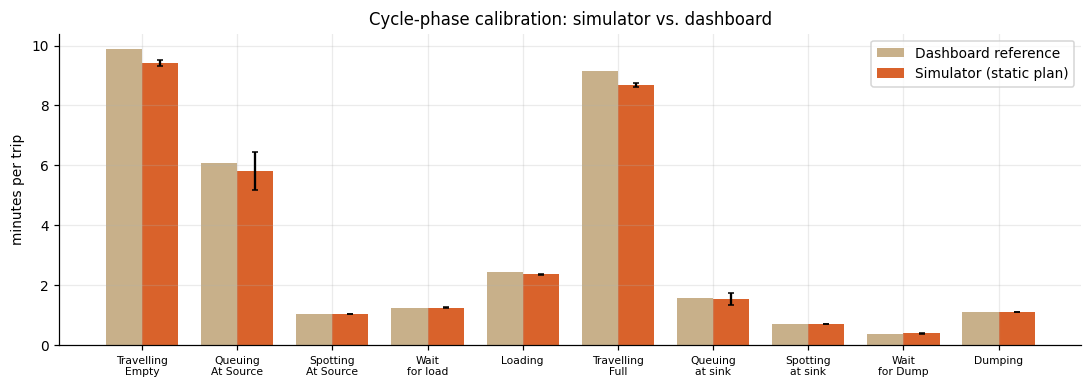

In [2]:
base, base_sims = replicate(Static, n=30, keep_sims=True)

# ---- (a) cycle phases -------------------------------------------------------------
phase_tab = pd.DataFrame({
    "Phase": PHASES,
    "Dashboard (min)": [REF[p] for p in PHASES],
    "Simulated (min)": [base[f"min_{i}"].mean() for i in range(10)],
    "±95% CI": [ci95(base[f"min_{i}"]) for i in range(10)]})
phase_tab["Error %"] = 100 * (phase_tab["Simulated (min)"] / phase_tab["Dashboard (min)"] - 1)
tot = pd.DataFrame([{"Phase": "TOTAL CYCLE", "Dashboard (min)": sum(REF.values()),
                     "Simulated (min)": base["cycle_time"].mean(), "±95% CI": ci95(base["cycle_time"]),
                     "Error %": 100 * (base["cycle_time"].mean() / sum(REF.values()) - 1)}])
display(pd.concat([phase_tab, tot]).round(2).reset_index(drop=True))

# ---- (b) headline KPIs --------------------------------------------------------------
kpi = pd.DataFrame({
    "KPI": ["Availability (%)", "Utilization (%)", "Throughput per productive hour (t/h)", "Shovel hang time (min)"],
    "Dashboard": [REF_KPI["availability"], REF_KPI["utilization"], REF_KPI["tph_productive"], REF_KPI["hang_time"]],
    "Simulated": [base["availability"].mean(), base["utilization"].mean(), base["tph_productive"].mean(), base["hang_time"].mean()],
    "±95% CI": [ci95(base[c]) for c in ["availability", "utilization", "tph_productive", "hang_time"]]})
kpi["Error %"] = 100 * (kpi["Simulated"] / kpi["Dashboard"] - 1)
display(kpi.round(2))

# ---- (c) figure ------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 3.6))
x = np.arange(10); w = 0.38
ax.bar(x - w/2, phase_tab["Dashboard (min)"], w, label="Dashboard reference", color="#c8b08a")
ax.bar(x + w/2, phase_tab["Simulated (min)"], w, yerr=phase_tab["±95% CI"], label="Simulator (static plan)", color="#d9622b", capsize=2)
ax.set_xticks(x); ax.set_xticklabels([p.replace(" ", "\n", 1) for p in PHASES], fontsize=7)
ax.set_ylabel("minutes per trip"); ax.set_title("Cycle-phase calibration: simulator vs. dashboard"); ax.legend()
plt.tight_layout(); plt.show()

In [3]:
# ---- 3.1  Which agreements are evidence? ---------------------------------------------------
status = pd.DataFrame([
    ("Spotting, wait, loading, dumping, sink spotting (phase means)", "input", "set to the dashboard values"),
    ("Travelling empty / full", "input", "shovel geometry chosen so that the mean matches"),
    ("Availability", "by construction", "MTBF / (MTBF + MTTR) = 10 / (10 + 1.85) = 84.4 %"),
    ("Queue at source", "tuned target", "static allocation 9-5-4-3-2 and process-delay probability"),
    ("Queue at sink", "tuned target", "crusher blockage frequency and duration"),
    ("Utilization", "tuned target", "process-delay probability"),
    ("Time split productive / queues / delays / maintenance", "mostly tuned", "follows from the targets above"),
    ("Shovel hang time", "INDEPENDENT CHECK", "not tuned -> fails (about x1.9)"),
    ("Fleet throughput (t/h)", "derived plausibility check", "depends on tuned fleet size, payload, cycle and availability; the dashboard window is uncertain (below)")],
    columns=["Quantity", "Status", "How it was obtained"])
display(status)

# ---- four-way split of fleet hours (dashboard: Productive / Queues / Delays / Maintenance) ----
G = lambda ss: sum(base[f"share_{s}"].mean() for s in ss)
sim_split = {"Productive": G([TE, SS, LD, TF, SK, DP, WL, WD]), "Queues": G([QS, QK]),
             "Delays": G([PD, RF, HD, E70, E110]), "Maintenance": G([DN, E60])}
dash_hours = {"Productive": 2695, "Queues": 793, "Delays": 583, "Maintenance": 753}       # hours, CEX Autonomous page
dash_total = sum(dash_hours.values())
split = pd.DataFrame({"Dashboard (% of 4,824 h)": {k: 100 * v / dash_total for k, v in dash_hours.items()},
                      "Simulator (% of fleet time)": sim_split})
split["Δ (points)"] = split.iloc[:, 1] - split.iloc[:, 0]
display(split.round(1))

# ---- independent, approximate checks: fleet throughput and fleet size --------------------------
moved = 2_120_663                                  # t, actual movement in the Throughput page
lo, hi = moved / (8 * 24), moved / 182.6           # 8 full days  vs  first record (9 Mar 08:00) to last update (16 Mar 22:34)
dyn_chk = replicate(lambda: GreedyObs(0), n=10)
print(f"Dashboard: {moved:,} t moved -> {lo:,.0f} t/h (8 full days) to {hi:,.0f} t/h (window of 182.6 h)")
print(f"Simulator: static plan {base.tph_fleet.mean():,.0f} t/h ; zero-lag greedy benchmark {dyn_chk.tph_fleet.mean():,.0f} t/h")
print(f"Fleet size: the dashboard shows 4,824 h in total = {dash_total/182.6:.1f} trucks over 182.6 h, versus 23 trucks modelled -> to be reconciled with the source")


Dashboard: 2,120,663 t moved -> 11,045 t/h (8 full days) to 11,614 t/h (window of 182.6 h)
Simulator: static plan 10,751 t/h ; zero-lag greedy benchmark 11,848 t/h
Fleet size: the dashboard shows 4,824 h in total = 26.4 trucks over 182.6 h, versus 23 trucks modelled -> to be reconciled with the source


,Quantity,Status,How it was obtained
0,"Spotting, wait, loading, dumping, sink spottin...",input,set to the dashboard values
1,Travelling empty / full,input,shovel geometry chosen so that the mean matches
2,Availability,by construction,MTBF / (MTBF + MTTR) = 10 / (10 + 1.85) = 84.4 %
3,Queue at source,tuned target,static allocation 9-5-4-3-2 and process-delay ...
4,Queue at sink,tuned target,crusher blockage frequency and duration
5,Utilization,tuned target,process-delay probability
6,Time split productive / queues / delays / main...,mostly tuned,follows from the targets above
7,Shovel hang time,INDEPENDENT CHECK,not tuned -> fails (about x1.9)
8,Fleet throughput (t/h),derived plausibility check,"depends on tuned fleet size, payload, cycle an..."


,"Dashboard (% of 4,824 h)",Simulator (% of fleet time),Δ (points)
Productive,55.9,57.4,1.5
Queues,16.4,16.8,0.3
Delays,12.1,11.1,-1.0
Maintenance,15.6,14.8,-0.8


### Input and output interpretation — calibration

The first table compares dashboard phase means with the simulator; the second compares headline KPIs; the status table distinguishes inputs, tuned targets, constructed quantities and checks.

* Phase means entered from the dashboard are reproduced closely. Travelling empty and full are 5.0 % and 4.8 % low, while the total TUM cycle is **32.24 min versus 33.51 min** (−3.79 %). These agreements mainly verify implementation because the phase durations are inputs.
* Availability is **85.24 % versus 84.39 %**. It is a constructed calibration quantity driven by the selected MTBF and MTTR, not independent validation. Queue at source (**5.81 versus 6.06 min**), queue at sink (**1.54 versus 1.56 min**) and utilization (**67.31 % versus 66.20 %**) are tuned targets.
* Throughput per productive hour is **814.86 versus 787.01 t/h** (+3.54 %). It is derived from the tuned fleet, payload, cycle and availability, so it is a plausibility check rather than an independent test.
* Shovel hang time is the informative failure: **4.41 versus 2.24 min** (+96.8 %). The structural sensitivity in Section 7 shows that the assumed number, availability and allocation of shovels materially affect this result.
* The fleet-hour split differs from the dashboard by at most 1.5 percentage points, but it inherits the calibration choices above.

**Output conclusion.** The model is internally coherent and close enough to the aggregate targets for controlled comparisons inside this twin. It is calibrated, not validated: matching these averages does not establish that the simulated queue mechanism is the one operating at Mine A.


## 4. TUM accounting — where does the fleet's time go?
Every truck-minute is assigned to one TUM bucket. The stacked bar shows the fleet-average split and the table derives the standard TUM parameters [TUM].

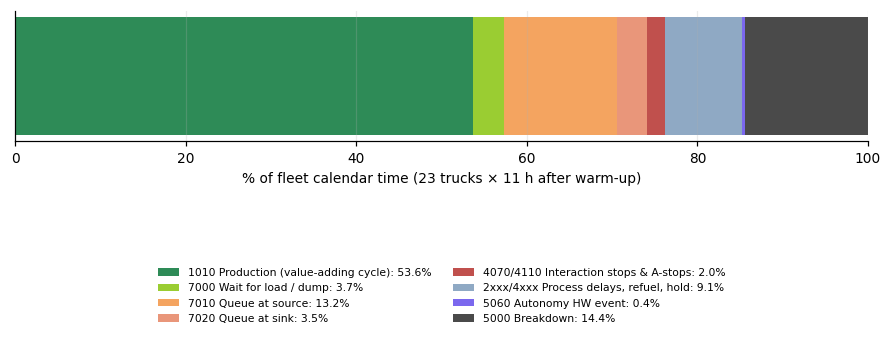

,TUM parameter,Value,Template range [KPI]
0,Required time (no standby 6xxx in this shift),100 % of calendar,—
1,Availability,85.2 %,> 85 %
2,Utilization (strict code 1010),62.9 %,> 60 %
3,Utilization (dashboard definition: cycle minus...,67.3 %,> 60 %
4,Total utilization (1010 / calendar),53.6 %,—
5,Annualised production time (1010 / calendar × ...,"4,698 h/yr per truck",—
6,"Non-value-adding cycle time (7000-7020), % of ...",20.5 % of calendar,< 10 % (unit and denominator unclear)
7,Non-value-adding share of cycle time (7000-702...,27.6 % (dashboard phases: 27.5 %),not comparable


In [4]:
groups = [("1010 Production (value-adding cycle)", [TE, SS, LD, TF, SK, DP], "#2e8b57"),
          ("7000 Wait for load / dump", [WL, WD], "#9acd32"),
          ("7010 Queue at source", [QS], "#f4a460"),
          ("7020 Queue at sink", [QK], "#e9967a"),
          ("4070/4110 Interaction stops & A-stops", [E70, E110], "#c0504d"),
          ("2xxx/4xxx Process delays, refuel, hold", [PD, RF, HD], "#8fa9c4"),
          ("5060 Autonomy HW event", [E60], "#7b68ee"),
          ("5000 Breakdown", [DN], "#4a4a4a")]
share = {g: sum(base[f"share_{s}"].mean() for s in sl) for g, sl, _ in groups}

fig, ax = plt.subplots(figsize=(10, 3.2)); left = 0
for g, sl, col in groups:
    ax.barh(0, share[g], left=left, color=col, label=f"{g}: {share[g]:.1f}%"); left += share[g]
ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xlabel("% of fleet calendar time (23 trucks × 11 h after warm-up)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.9), ncol=2, fontsize=7, frameon=False)
fig.subplots_adjust(bottom=0.6, top=0.97); plt.show()

cal = base[[f"share_{s}" for s in range(17)]].mean().sum()          # = 100
down = sum(base[f"share_{s}"].mean() for s in DOWN_SLOTS)
prod1010 = share[groups[0][0]]
prod_dash = prod1010 + share[groups[1][0]]
nva = share[groups[1][0]] + share[groups[2][0]] + share[groups[3][0]]
tum = pd.DataFrame({"TUM parameter": ["Required time (no standby 6xxx in this shift)", "Availability", "Utilization (strict code 1010)",
                                      "Utilization (dashboard definition: cycle minus queues)", "Total utilization (1010 / calendar)",
                                      "Annualised production time (1010 / calendar × 8 760)", "Non-value-adding cycle time (7000-7020), % of calendar", "Non-value-adding share of cycle time (7000-7020 / (1010 + 7000-7020))"],
                    "Value": [f"{cal:.0f} % of calendar", f"{100-down:.1f} %", f"{100*prod1010/(100-down):.1f} %",
                              f"{100*prod_dash/(100-down):.1f} %", f"{prod1010:.1f} %",
                              f"{prod1010/100*8760:,.0f} h/yr per truck",
                              f"{nva:.1f} % of calendar", f"{100*nva/(prod1010+nva):.1f} %  (dashboard phases: 27.5 %)"],
                    "Template range [KPI]": ["—", "> 85 %", "> 60 %", "> 60 %", "—", "—", "< 10 % (unit and denominator unclear)", "not comparable"]})
display(tum)

### Input and output interpretation — TUM accounting

* Code 1010 production occupies **53.6 % of calendar time**, equivalent to **4,698 h/year per truck** under the TUM × 8,760 convention.
* Availability is **85.2 %**; utilization is **62.9 %** under strict code 1010 and **67.3 %** under the dashboard definition that also counts wait-for-load and wait-for-dump. Both utilization measures exceed the template's 60 % threshold; availability only narrowly exceeds 85 %.
* Codes 7000–7020 occupy **20.5 % of calendar time** and **27.6 % of cycle time**, essentially the same cycle share as the dashboard phases (27.5 %). The template's “< 10 %” line has an unclear unit and denominator, so it is not used as a pass/fail comparison.
* The 7000–7020 block is not wholly dispatch-removable. Source queues are partly allocation-sensitive, waits may be communication-sensitive, and some queueing is unavoidable. Notebooks 1–3 estimate conditional changes for specified mechanisms; they do not treat the full 20.5 % as recoverable.
* The 4.4-point gap between the two utilization definitions comes from wait-for-load and wait-for-dump. Every reported utilization should therefore name its denominator and included phases.


## 5. Dispatch benchmark with a current zero-lag snapshot
The baseline source queue is generated by the twin's assumed home allocation. This experiment compares it with a greedy dispatcher that sees the **current committed-truck counts and shovel up/down flags** with zero observation lag. It does not see the full physical state, and it is not a mathematical upper bound. The result is a benchmark conditional on this model and this information set.


Zero-lag greedy minus static: +1173 t/h (95% CI +974 to +1372)


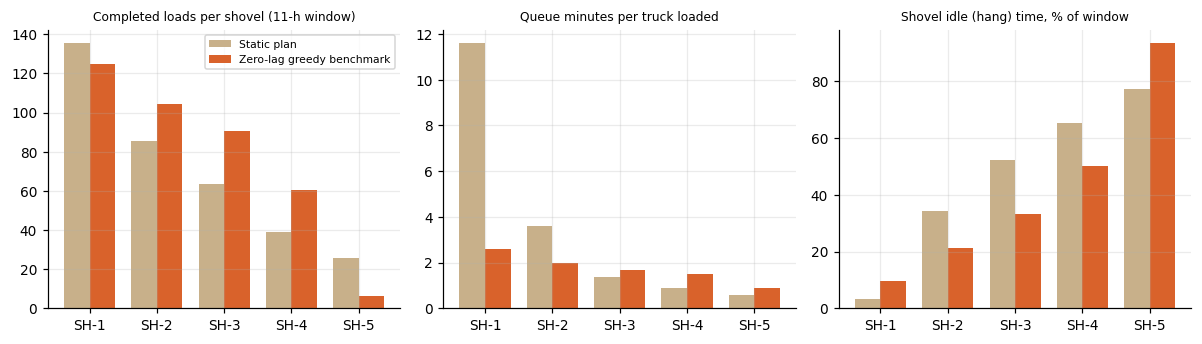

,Static plan,Zero-lag greedy,Δ %
Fleet throughput (t/h),10751.47,11924.23,10.91
Cycle time (min),32.24,28.47,-11.71
Queue at source (min/trip),5.81,2.00,-65.52
Hang time (min),4.41,3.56,-19.33
Utilization (%),67.31,74.81,11.14


In [5]:
dyn = replicate(lambda: GreedyObs(0), n=30)
sh = [f"SH-{a+1}" for a in range(5)]
def per_shovel(df):
    L = np.vstack(df["loads"]); Q = np.vstack(df["qtime"]); I = np.vstack(df["idle"])
    return L.mean(0), (Q / np.maximum(L, 1)).mean(0), 100 * I.mean(0) / (P().T - P().warm)
Ls, Qs, Is = per_shovel(base); Ld, Qd, Id = per_shovel(dyn)

fig, axs = plt.subplots(1, 3, figsize=(11, 3.2))
x = np.arange(5); w = 0.38
for ax, (a, b, t) in zip(axs, [(Ls, Ld, "Completed loads per shovel (11-h window)"), (Qs, Qd, "Queue minutes per truck loaded"), (Is, Id, "Shovel idle (hang) time, % of window")]):
    ax.bar(x - w/2, a, w, label="Static plan", color="#c8b08a"); ax.bar(x + w/2, b, w, label="Zero-lag greedy benchmark", color="#d9622b")
    ax.set_xticks(x); ax.set_xticklabels(sh); ax.set_title(t, fontsize=8)
axs[0].legend(fontsize=7); plt.tight_layout(); plt.show()

cmp = pd.DataFrame({"Static plan": [base[c].mean() for c in ["tph_fleet", "cycle_time", "queue_src", "hang_time", "utilization"]],
                    "Zero-lag greedy": [dyn[c].mean() for c in ["tph_fleet", "cycle_time", "queue_src", "hang_time", "utilization"]]},
                   index=["Fleet throughput (t/h)", "Cycle time (min)", "Queue at source (min/trip)", "Hang time (min)", "Utilization (%)"])
cmp["Δ %"] = 100 * (cmp["Zero-lag greedy"] / cmp["Static plan"] - 1)
display(cmp.round(2))
# Seed-indexed difference; identical seed indices do not imply identical event histories once policies diverge.

d_throughput = dyn.tph_fleet.values - base.tph_fleet.values
print(f"Zero-lag greedy minus static: {d_throughput.mean():+.0f} t/h (95% CI {d_throughput.mean()-ci95(d_throughput):+.0f} to {d_throughput.mean()+ci95(d_throughput):+.0f})")


### Input and output interpretation — dispatch benchmark

* The home-allocation plan overloads the nearest shovel and leaves capacity idle elsewhere. It includes an 8-min fail-safe diversion when the assigned shovel is unavailable; it is therefore “static” in normal routing, not under every failure.
* The zero-lag greedy benchmark raises fleet throughput from **10,751 to 11,924 t/h**: **+1,173 t/h**, with a seed-indexed 95 % interval for the difference of **+974 to +1,372 t/h**. The relative gain is **10.9 %**.
* Queue at source falls from **5.81 to 2.00 min/trip** (−65.5 %), cycle time from **32.24 to 28.47 min** (−11.7 %), and hang time from **4.41 to 3.56 min** (−19.3 %). Dashboard-definition utilization rises from 67.31 % to 74.81 %.
* The routing change also changes the shovel/haul mix. Because the model has no grade, blend, phase or production-plan constraints, the productivity gain is not directly deployable as a mine plan.

**Output conclusion.** Current allocation information has substantial value in the assumed imbalanced twin. The number is a model-conditional benchmark, not a site-wide upper bound.


## 6. Verification checks
Before trusting any experiment we check that the simulator obeys conservation laws [BANKS][LAW].

In [6]:
s0 = base_sims[0]
expected = s0.N * (s0.p.T - s0.p.warm)
print(f"1) Time conservation: accounted truck-minutes = {s0.acct.sum():,.0f}  vs  expected 23 x {s0.p.T-s0.p.warm:.0f} = {expected:,.0f}")

# 2) Little's law for the closed loop: L = lambda * W  ->  trips/min x mean wall-clock cycle = trucks in the system (=23)
L_est = [ (s.trips / (s.p.T - s.p.warm)) * np.mean(s.cycles) for s in base_sims]
print(f"2) Little's law: lambda*W = {np.mean(L_est):.1f} trucks (should be ~23; small negative bias comes from truncating cycles at the shift end)")

# 3) deterministic reproducibility: same policy and seed -> identical result
a = Sim(P(seed=7), Static()).run()["tph_fleet"]; b = Sim(P(seed=7), Static()).run()["tph_fleet"]
print(f"3) Reproducibility: same seed twice -> {a:.1f} and {b:.1f} t/h")

# 4) sanity of extremes: more trucks, same shovels -> more queue, throughput saturates
rows = []
for n in [12, 18, 23, 28, 34]:
    d = replicate(lambda: GreedyObs(0), n=8, n_trucks=n, static_alloc=(n,0,0,0,0))
    rows.append((n, d.tph_fleet.mean(), d.queue_src.mean(), d.utilization.mean()))
display(pd.DataFrame(rows, columns=["Trucks", "Throughput (t/h)", "Queue at source (min)", "Utilization (%)"]).round(1))


1) Time conservation: accounted truck-minutes = 15,180  vs  expected 23 x 660 = 15,180
2) Little's law: lambda*W = 22.6 trucks (should be ~23; small negative bias comes from truncating cycles at the shift end)
3) Reproducibility: same seed twice -> 10539.5 and 10539.5 t/h


,Trucks,Throughput (t/h),Queue at source (min),Utilization (%)
0,12,7032.7,1.5,76.4
1,18,9748.2,1.7,76.8
2,23,11864.6,2.0,74.2
3,28,13769.7,2.6,72.7
4,34,15244.6,3.6,67.8


### Input and output interpretation — verification

1. **Time conservation:** the simulator accounts for exactly **15,180 truck-minutes**, equal to 23 trucks × 660 post-warm-up minutes.
2. **Little's law:** using completed trips per minute and the measured **wall-clock inter-dump cycle**, λW is **22.6 trucks** versus 23. The small shortfall is consistent with cycles truncated at the end of the observation window. This check uses the wall-clock cycle, not the 32.24-min TUM phase sum.
3. **Deterministic reproducibility:** the same policy and seed reproduce **10,539.5 t/h** twice. This verifies deterministic execution; it does **not** mean different policies experience identical event histories.
4. **Extremes:** with the same shovels, increasing the fleet from 12 to 34 trucks raises throughput from **7,033 to 15,245 t/h**, while source queue rises from 1.5 to 3.6 min and utilization eventually falls to 67.8 %. The direction is consistent with congestion and diminishing returns.


## 7. Structural sensitivity — how much do the conclusions depend on the assumed queue mechanism?
Section 3.1 showed that the twin's queue at source is *tuned*. The dashboard's SHOVEL page gives per-shovel evidence that the mechanism assumed by the twin (an imbalanced static allocation over five shovels) may not be the real one. Reference-week data, hours per shovel out of ≈ 181 h [DASH] (shovels anonymised):

| Shovel | Hang time | Dark-orange segment* | Machine delay | Wait for spot |
|---|---|---|---|---|
| A | 64 | 46 | 59 | 12 |
| B | 61 | – | 121 | – |
| C | 68 | 65 | 36 | 12 |
| D | 58 | 45 | 68 | 10 |
| E | 71 | 45 | 54 | 11 |
| F | – | – | 180 | – |

\*The dark-orange segment is *Loading* or *NOT_DETERMINED*; the legend colours are too close to tell.

**Three observations.** (i) Only four shovels (A, C, D, E) show loading-like time, in line with the four shovels of the tonnage chart; B and F are essentially out of service. The twin assumes five active shovels. (ii) Hang time is almost uniform across the four working shovels (58–71 h, 32–39 % of the time), whereas the twin's static plan gives idle shares from 3 % to 77 %. (iii) Machine delay is 20–38 % of the time at the working shovels, against ≈ 5 % in the twin.

We therefore re-run the static-versus-dynamic comparison under five structural variants (12 replications each) and ask which conclusions survive.

In [7]:
four = dict(te=(7.0, 9.1, 10.2, 12.8), tf=(6.6, 8.6, 9.6, 11.8), load=(2.2, 2.4, 2.4, 2.6))
VARIANTS = {
    "V0 twin as calibrated: 5 shovels, static 9-5-4-3-2, shovel availability 95 %": dict(),
    "V1 5 shovels, balanced static 5-5-5-4-4, shovel availability 95 %": dict(static_alloc=(5, 5, 5, 4, 4)),
    "V2 as V1 + shovel availability ~70 % (MTBF 4 h, MTTR 1.7 h)": dict(static_alloc=(5, 5, 5, 4, 4), shovel_mtbf_h=4.0, shovel_mttr_h=1.7),
    "V3 4 shovels, balanced 6-6-6-5, shovel availability ~70 %": dict(**four, static_alloc=(6, 6, 6, 5), shovel_mtbf_h=4.0, shovel_mttr_h=1.7),
    "V4 4 shovels, balanced 6-6-6-5, shovel availability 95 %": dict(**four, static_alloc=(6, 6, 6, 5)),
}
rows = []
for name, kw in VARIANTS.items():
    s = replicate(Static, n=12, **kw); g = replicate(lambda: GreedyObs(0), n=12, **kw)
    idle = 100 * np.mean(np.vstack(s["idle"]), 0) / (P().T - P().warm)
    rows.append({"Variant": name, "Static t/h": s.tph_fleet.mean(), "Static queue src (min)": s.queue_src.mean(),
                 "Static hang (min)": s.hang_time.mean(), "Static util %": s.utilization.mean(),
                 "Dynamic t/h": g.tph_fleet.mean(), "Dynamic queue src (min)": g.queue_src.mean(),
                 "Gain %": 100 * (g.tph_fleet.mean() / s.tph_fleet.mean() - 1),
                 "Seed-indexed Δ t/h": (g.tph_fleet.values - s.tph_fleet.values).mean(),
                 "Δ 95% CI half-width": ci95(g.tph_fleet.values - s.tph_fleet.values),
                 "Static shovel idle % (per shovel)": str(np.round(idle).astype(int).tolist())})
sens = pd.DataFrame(rows)
display(sens.round(1))
print(f"Dashboard reference: queue at source 6.06 min, hang time 2.24 min, utilization 66.2 %, ~11 000-11 600 t/h")


Dashboard reference: queue at source 6.06 min, hang time 2.24 min, utilization 66.2 %, ~11 000-11 600 t/h


,Variant,Static t/h,Static queue src (min),Static hang (min),Static util %,Dynamic t/h,Dynamic queue src (min),Gain %,Seed-indexed Δ t/h,Δ 95% CI half-width,Static shovel idle % (per shovel)
0,"V0 twin as calibrated: 5 shovels, static 9-5-4...",10611.2,5.9,4.5,66.5,11853.0,2.0,11.7,1241.9,345.7,"[3, 34, 53, 68, 78]"
1,"V1 5 shovels, balanced static 5-5-5-4-4, shove...",11197.5,2.5,4.0,75.2,11853.0,2.0,5.9,655.5,332.8,"[26, 35, 43, 56, 60]"
2,V2 as V1 + shovel availability ~70 % (MTBF 4 h...,8923.7,10.8,3.3,62.4,10429.3,4.9,16.9,1505.6,685.5,"[11, 23, 25, 42, 43]"
3,"V3 4 shovels, balanced 6-6-6-5, shovel availab...",8373.2,14.3,1.9,56.9,10303.9,7.0,23.1,1930.7,749.7,"[9, 14, 22, 32]"
4,"V4 4 shovels, balanced 6-6-6-5, shovel availab...",11276.9,3.3,2.3,71.6,11786.5,2.4,4.5,509.6,182.7,"[18, 28, 34, 49]"


### Input and output interpretation — structural sensitivity

* The direction is stable in the five tested variants: the zero-lag greedy policy exceeds the home-allocation plan in every case, and every direct 95 % interval for the seed-indexed throughput difference is above zero.
* The magnitude is **not** stable. Gains range from **+4.5 % (V4)** and **+5.9 % (V1)** with reliable, balanced structures to **+16.9 % (V2)** and **+23.1 % (V3)** when shovel availability is about 70 %. The calibrated five-shovel case gives +11.7 % in this 12-replication sensitivity run.
* V4 (four reliable shovels) gives **2.3 min hang time**, close to the 2.24-min dashboard value, and **11,277 t/h**, inside the approximate dashboard range. It still misses other targets: source queue is 3.3 min and utilization 71.6 %. Because V4 was examined after seeing the hang-time discrepancy, this is a post-hoc structural check, not independent validation.
* The unreliable four-shovel case V3 matches neither the queue nor utilization: source queue reaches 14.3 min and utilization falls to 56.9 %. No tested variant reproduces all targets simultaneously.

**Output conclusion.** The sign of the comparison survives the tested structures, but its size is highly model-dependent. The observed range belongs to these five scenarios only; it is not a blanket uncertainty band that can be added to every result in the series.


## Limitations

* The twin is reduced-form: one crusher, four or five abstract shovels depending on the sensitivity case, one route per shovel, and no bench geometry, grade/blend, weather, road network or production-plan constraints.
* Event rates, blockage durations and several reliability/process parameters are assumptions or calibration choices. Only held-out FMS event data can test the mechanism.
* Confidence intervals use Student's *t* distribution over independent simulated shifts. Policy comparisons report intervals for the **direct seed-indexed difference**; comparing two separate marginal error bars is not a test of their difference.
* Environment and policy random generators are separated. Nevertheless, once policies choose different routes, the state-dependent sequence of later events can diverge; equal seed indices are not identical physical histories.
* The baseline queue is created by a deliberately imbalanced home allocation. Dashboard shovel data suggest a different structure, and Section 7 shows that the estimated gain is sensitive to that choice.
* The dashboard's total fleet hours imply about 26.4 trucks over the stated 182.6-h window, not the 23 trucks modelled. The source window and active fleet should be reconciled before site-level use.
* Aggregate calibration is not validation. A final operational model requires a held-out time period, event-level calibration, and acceptance criteria defined before observing the validation outputs.


## References

1. **[TUM]** Operator's *Operations & Supply Chain Management – Time Usage Model (TUM): Our Requirements*, v7.0 (12 Jan 2023), internal standard (Company X). Time definitions, classification categories, parameters (availability, utilization, annualised production time), reliability parameters (MTBF, MTTR) and the standard time codes.
2. **[DASH]** Autonomous-haulage operations dashboard pack ("Autonomous-Haulage Dashboard"), Mine A, extracts for 9–16 March 2025: Tonnage Origin/Destination, Crusher Feed, Availability, Utilization, Throughput, Autonomous Fleet (cycle phases), Shovel, Duration, Annualised, and the dashboard-by-dashboard KPI list.
3. **[GLOS]** *Full TUM Glossary* – general time terms, downtime classification, standard parameters, reliability parameters and code families.
4. **[KPI]** *KPI Control Template – Mine A (improved version)* – expected ranges: availability > 85 %, utilization > 60 %, MTBF > 10 h, MTTR < 2 h, hang time < 2 min, load factor 2.5–3 passes, non-productive time (7000–7020) < 10 %.
5. **[CYCLE]** Mining haul-cycle diagram: ten cycle phases – travelling empty, queuing/spotting at source, wait for load, loading, travelling full, queuing/spotting at sink, wait for dump, dumping.
6. **[BANKS]** Banks, J., Carson, J. S., Nelson, B. L. & Nicol, D. M. (2010). *Discrete-Event System Simulation* (5th ed.). Pearson. (Warm-up, replications, confidence intervals, verification and validation.)
7. **[LAW]** Law, A. M. (2015). *Simulation Modeling and Analysis* (5th ed.). McGraw-Hill.
8. **[LITTLE]** Little, J. D. C. (1961). A proof for the queuing formula L = λW. *Operations Research*, 9(3), 383–387.
9. **[AG]** Alarie, S. & Gamache, M. (2002). Overview of solution strategies used in truck dispatching systems for open pit mines. *International Journal of Surface Mining, Reclamation and Environment*, 16(1), 59–76.


## Disclaimer

This notebook is an exploratory simulation based on anonymised aggregate indicators and a simplified representation of an open-pit haulage system. It is not an operator model, a production forecast, a safety case or an operating recommendation. Parameters that were not observable—including event rates, communication effects and human-response times—are explicit assumptions, and the outputs are conditional on those assumptions and on the model structure.

Company, mine, location and equipment identifiers have been anonymised. The work is independent and is not endorsed by, or affiliated with, any mining company or technology vendor. Operational, investment and safety decisions require validation against held-out FMS event data, mine-plan constraints and the applicable engineering and safety standards.
